In [8]:
# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

SERVER = "DESKTOP-LKG2222"
DATABASE = "FashionEcommerce"
engine = create_engine(
    f"mssql+pyodbc://{SERVER}/{DATABASE}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
    "&TrustServerCertificate=yes"
)

In [9]:
# ── Charger le CA mensuel (déjà utilisé en Phase 8) ──
query_monthly = """
SELECT d.[Year], d.[Month],
       SUM(f.Line_Total_USD) AS Revenue_USD
FROM warehouse.vw_Fact_Sales_USD f
JOIN warehouse.Dim_Date d ON f.Date_Key = d.Date_Key
WHERE f.Transaction_Type = 'Sale'
GROUP BY d.[Year], d.[Month]
ORDER BY d.[Year], d.[Month];
"""
monthly = pd.read_sql(query_monthly, engine)
monthly["Period"] = pd.to_datetime(monthly["Year"].astype(str) + "-" + monthly["Month"].astype(str) + "-01")
monthly = monthly.set_index("Period")["Revenue_USD"]
monthly.index.freq = "MS"  # Month Start, requis par statsmodels

print(f"{len(monthly)} mois de données, de {monthly.index.min().date()} à {monthly.index.max().date()}")

# ⚠️ Le dernier mois (mars 2025) est probablement incomplet (données jusqu'au 18 mars) -> on l'exclut du modèle
monthly_clean = monthly.iloc[:-1]
print(f"Dernier mois utilisé: {monthly_clean.index.max().date()}")

27 mois de données, de 2023-01-01 à 2025-03-01
Dernier mois utilisé: 2025-02-01


MAPE sur les 2 derniers mois: 37.14%
RMSE: 2,233,786 USD


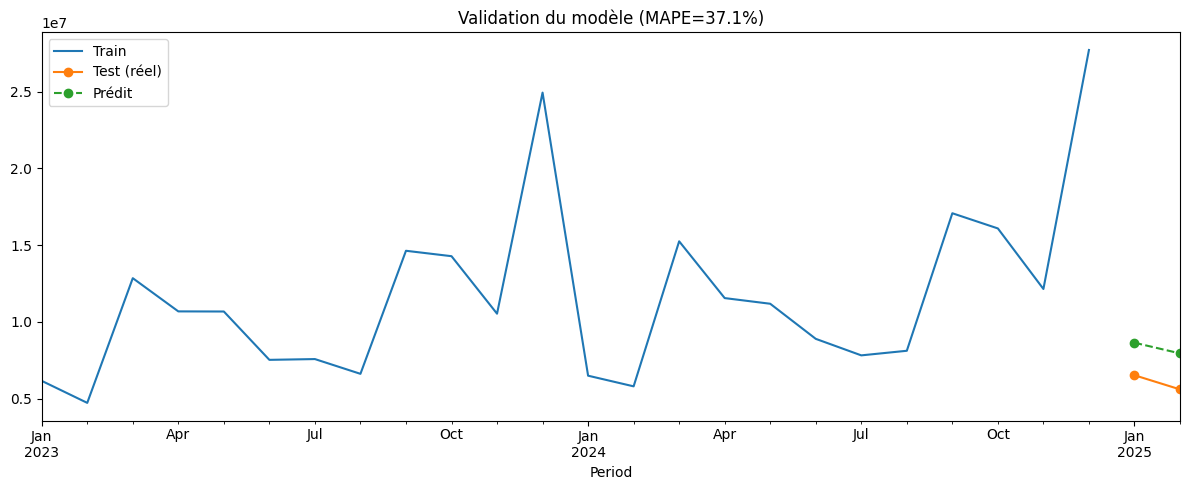

In [10]:
# ── Validation : train sur tout sauf les 2 derniers mois, test sur ces 2 mois ──
train = monthly_clean.iloc[:-2]
test = monthly_clean.iloc[-2:]

model_val = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=12,
    initialization_method="estimated"
).fit()

forecast_val = model_val.forecast(2)

mape = mean_absolute_percentage_error(test, forecast_val) * 100
rmse = np.sqrt(mean_squared_error(test, forecast_val))

print(f"MAPE sur les 2 derniers mois: {mape:.2f}%")
print(f"RMSE: {rmse:,.0f} USD")

fig, ax = plt.subplots(figsize=(12, 5))
train.plot(ax=ax, label="Train")
test.plot(ax=ax, label="Test (réel)", marker="o")
forecast_val.plot(ax=ax, label="Prédit", marker="o", linestyle="--")
ax.set_title(f"Validation du modèle (MAPE={mape:.1f}%)")
ax.legend()
plt.tight_layout()
plt.show()

Prévision des 3 prochains mois (USD):
2025-03-01    16021429.0
2025-04-01    12233456.0
2025-05-01    11793274.0
Freq: MS, dtype: float64


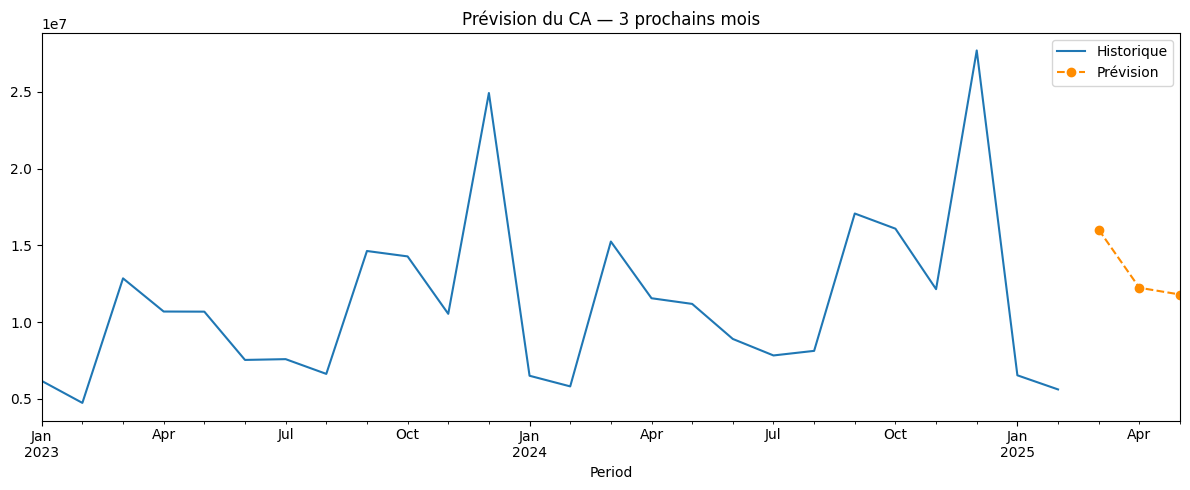

In [11]:
# ── Modèle final : entraîné sur TOUT l'historique propre, prévision des 3 prochains mois ──
model_final = ExponentialSmoothing(
    monthly_clean, trend="add", seasonal="add", seasonal_periods=12,
    initialization_method="estimated"
).fit()

forecast_next3 = model_final.forecast(3)
print("Prévision des 3 prochains mois (USD):")
print(forecast_next3.round(0))

fig, ax = plt.subplots(figsize=(12, 5))
monthly_clean.plot(ax=ax, label="Historique")
forecast_next3.plot(ax=ax, label="Prévision", marker="o", linestyle="--", color="darkorange")
ax.set_title("Prévision du CA — 3 prochains mois")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# ── Export vers SQL Server (pour Power BI) ──
forecast_export = pd.DataFrame({
    "Period": forecast_next3.index,
    "Forecast_Revenue_USD": forecast_next3.values,
    "Model_MAPE_Pct": mape
})
forecast_export.to_sql(
    "Revenue_Forecast",
    engine,
    schema="warehouse",
    if_exists="replace",
    index=False
)
print("Prévisions exportées vers warehouse.Revenue_Forecast")

Prévisions exportées vers warehouse.Revenue_Forecast
